# DATA CLEANING

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [131]:
# Read all sheets at once → returns a dictionary {sheet_name: dataframe}
sheets = pd.read_excel(r'C:\Users\ysyzy\.ipynb_checkpoints\Marketing_analysis\data\marketing_dataset.xlsx', sheet_name=None)

# See all sheet names
print(sheets.keys())

# Access each one
marketing = sheets["Campaign_Data"]  # replace with your actual sheet names
campaigns = sheets["Campaigns"]
channels  = sheets["Channels"]
leads     = sheets["Leads"]

# Quick check
for name, df in sheets.items():
    print(f"\n--- {name} ---")
    print(df.shape)        # rows x columns
    print(df.head(2))

dict_keys(['Campaign_Data', 'Campaigns', 'Channels', 'Leads'])

--- Campaign_Data ---
(3000, 11)
  Campaign_ID                Date   Campaign_Name     Channel    Region  \
0      CMP969 2025-02-04 09:07:00  Ramadan offer    Instagram  Mansoura   
1      CMP603 2023-02-05 21:47:00   Ramadan Offer  Google Ads    Cairo    

   Impressions  Clicks  Spend  Conversions  Revenue   Device  
0      40006.0    3692   8800          238    35274   Tablet  
1      22122.0    1804   5787          486    27702  Desktop  

--- Campaigns ---
(20, 5)
  Campaign_ID Campaign_Name          Start_Date            End_Date  Budget
0      CMP100   Summer Sale 2024-02-03 15:40:00 2024-03-25 15:40:00   33070
1      CMP101  Black Friday 2025-04-01 16:32:00 2025-05-30 16:32:00   42649

--- Channels ---
(5, 3)
   Channel_ID Channel_Name  Type
0           1     Facebook  Paid
1           2   Google Ads  Paid

--- Leads ---
(1000, 6)
  Lead_ID                Date Campaign_ID     Channel     Status  Score
0   L5928 20

In [132]:
marketing.isnull().sum()

Campaign_ID        0
Date               0
Campaign_Name      0
Channel            0
Region           481
Impressions       60
Clicks             0
Spend              0
Conversions        0
Revenue            0
Device             0
dtype: int64

In [133]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()        # remove spaces around name
        .str.lower()        # lowercase
        .str.replace(" ", "_")   # spaces → underscore
        .str.replace("-", "_")   # dashes → underscore
    )
    return df

In [134]:
marketing = clean_columns(marketing)
campaigns = clean_columns(campaigns)
channels  = clean_columns(channels)
leads     = clean_columns(leads)

for name, df in zip(["marketing","campaigns","channels","leads"],
                    [marketing, campaigns, channels, leads]):
    print(f"\n{name}: {df.columns.tolist()}")


marketing: ['campaign_id', 'date', 'campaign_name', 'channel', 'region', 'impressions', 'clicks', 'spend', 'conversions', 'revenue', 'device']

campaigns: ['campaign_id', 'campaign_name', 'start_date', 'end_date', 'budget']

channels: ['channel_id', 'channel_name', 'type']

leads: ['lead_id', 'date', 'campaign_id', 'channel', 'status', 'score']


# EDA (Exploratory Data Analysis)

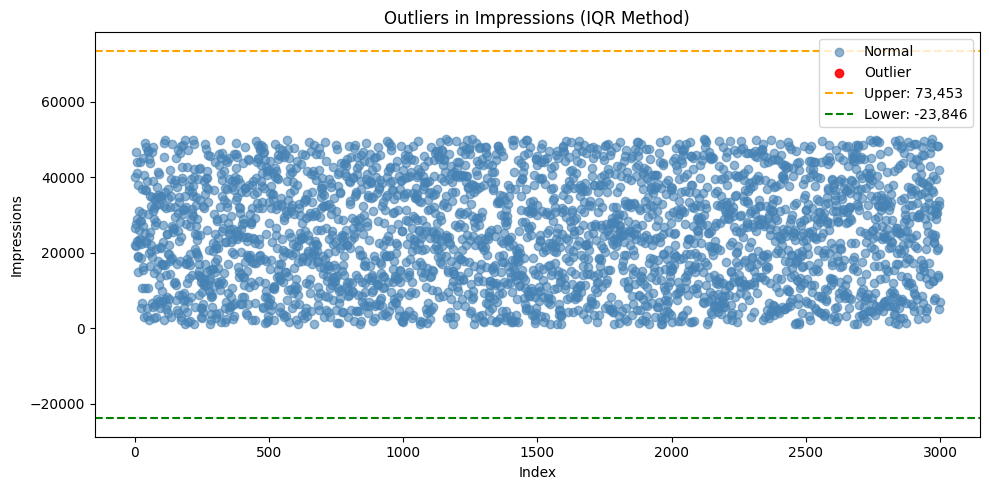

Total outliers: 0
Upper bound: 73,453
Lower bound: -23,846


In [135]:
Q1 = marketing["impressions"].quantile(0.25)
Q3 = marketing["impressions"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Flag outliers ---
marketing["is_outlier"] = (marketing["impressions"] < lower) | (marketing["impressions"] > upper)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

# Normal points
ax.scatter(
    x=marketing[~marketing["is_outlier"]].index,
    y=marketing[~marketing["is_outlier"]]["impressions"],
    color="steelblue", label="Normal", alpha=0.6
)

# Outlier points
ax.scatter(
    x=marketing[marketing["is_outlier"]].index,
    y=marketing[marketing["is_outlier"]]["impressions"],
    color="red", label="Outlier", alpha=0.9
)

# Boundary lines
ax.axhline(upper, color="orange", linestyle="--", label=f"Upper: {upper:,.0f}")
ax.axhline(lower, color="green",  linestyle="--", label=f"Lower: {lower:,.0f}")

ax.set_title("Outliers in Impressions (IQR Method)")
ax.set_xlabel("Index")
ax.set_ylabel("Impressions")
ax.legend()
plt.tight_layout()
plt.show()

# --- Summary ---
print(f"Total outliers: {marketing['is_outlier'].sum()}")
print(f"Upper bound: {upper:,.0f}")
print(f"Lower bound: {lower:,.0f}")

#### there is no outlier so we can fill the blanks usnig methods like mean 

In [136]:
marketing['impressions'].fillna(marketing['impressions'].mean(),inplace=True)

C:\Users\ysyzy\AppData\Local\Temp\ipykernel_14712\321505283.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  marketing['impressions'].fillna(marketing['impressions'].mean(),inplace=True)


In [137]:
# Check if missing region has a pattern
print(marketing[marketing["region"].isna()]["channel"].value_counts())
print(marketing[marketing["region"].isna()]["campaign_name"].value_counts())

channel
GOOGLE ADS    78
TikTok        73
Google Ads    71
Email         71
facebook      67
Facebook      66
Instagram     55
Name: count, dtype: int64
campaign_name
Discount Blast    74
Black Friday      72
summer sale       70
Ramadan Offer     69
Summer Sale       69
New Launch        64
Ramadan offer     63
Name: count, dtype: int64


In [138]:
marketing['region'] = marketing['region'].str.strip().str.title()
marketing['channel'] = marketing['channel'].str.strip().str.title()
marketing['campaign_name'] = marketing['campaign_name'].str.strip().str.title()

marketing.duplicated().sum()


np.int64(0)

In [139]:
leads.isnull().sum()
leads['status'].fillna('Unknown', inplace=True)
leads['status'] = leads['status'].str.strip().str.title()


C:\Users\ysyzy\AppData\Local\Temp\ipykernel_14712\1524281332.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  leads['status'].fillna('Unknown', inplace=True)


# Channel Analysis 

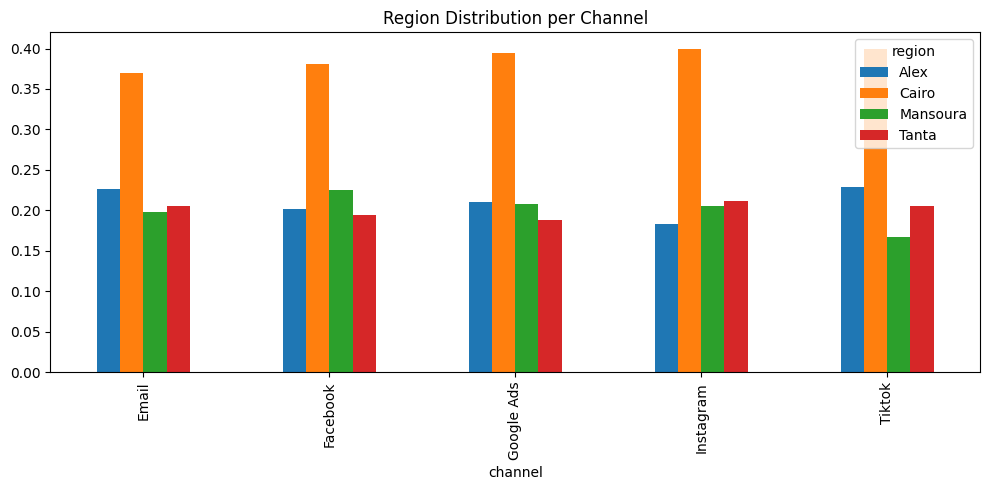

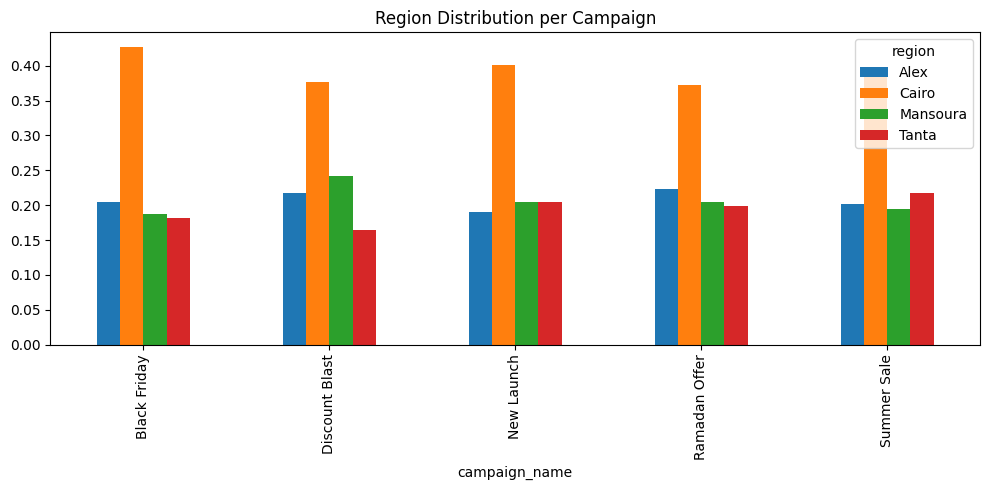

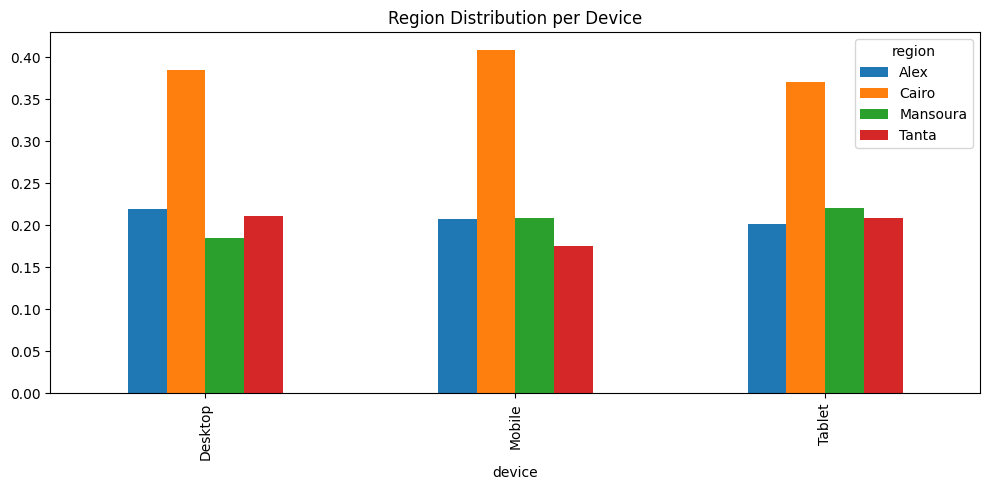

In [140]:
known = marketing[marketing['region'].notna()].copy()
pd.crosstab(known['channel'],known['region'],normalize="index").plot(kind='bar',title='Region Distribution per Channel',figsize=(10,5))
plt.tight_layout()
plt.show()
pd.crosstab(known['campaign_name'],known['region'],normalize="index").plot(kind='bar',title='Region Distribution per Campaign',figsize=(10,5))
plt.tight_layout()
plt.show()
pd.crosstab(known['device'],known['region'],normalize="index").plot(kind='bar',title='Region Distribution per Device',figsize=(10,5))
plt.tight_layout()
plt.show()

In [141]:
marketing['region'] = marketing['region'].fillna('Unknown')

In [142]:
marketing['region'].value_counts()

region
Cairo       978
Alex        527
Mansoura    515
Tanta       499
Unknown     481
Name: count, dtype: int64

In [143]:
leads.isnull().sum()


lead_id        0
date           0
campaign_id    0
channel        0
status         0
score          0
dtype: int64

In [144]:
leads['status'] = leads['status'].str.strip().str.title()

### Status Distribution per Channel

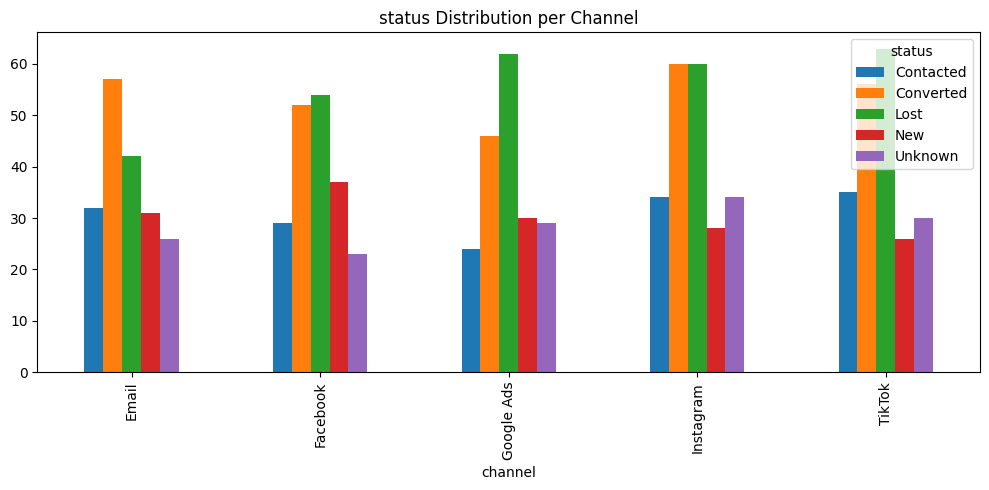

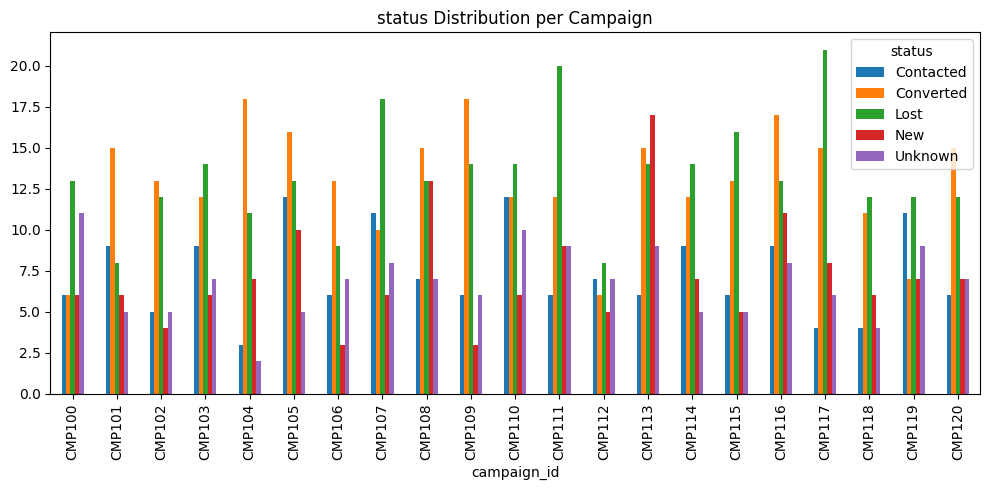

In [145]:
known = leads[leads['status'].notna()].copy()
pd.crosstab(known['channel'],known['status']).plot(kind='bar',title='status Distribution per Channel',figsize=(10,5))
plt.tight_layout()
plt.show()
pd.crosstab(known['campaign_id'],known['status']).plot(kind='bar',title='status Distribution per Campaign',figsize=(10,5))
plt.tight_layout()
plt.show()

Observations: 

Lost is winning everywhere. Across all five channels, the green bar is either the tallest or tied for tallest. That's not a channel problem — that's a funnel problem. Something is breaking after the lead comes in.
Google Ads and TikTok are the worst offenders. Both have Lost sitting at ~62%, and their Converted numbers (~46 and ~56) don't come close to compensating. You're paying for clicks, generating leads, then watching most of them walk away.
Instagram is interesting. It has the highest Converted count (~60) but also a Lost rate (~60) that matches it almost exactly. So Instagram is generating real buyers — just not reliably. Half convert, half disappear. That's a qualification problem, not a traffic problem.
Email is the most balanced channel on this chart. Contacted, Converted, Lost, and New are all sitting in a tight band between 31–45. No single status is dominating. For a cheap channel, that's actually a decent result.
Facebook sits quietly in the middle — nothing spectacular, nothing alarming. Converted (~52) is slightly below Lost (~54), which is fine. The gap is small enough that a small improvement in follow-up could flip it.

### ROI Distribution per Channel

<Axes: title={'center': 'ROI Distribution per Channel'}, xlabel='channel'>

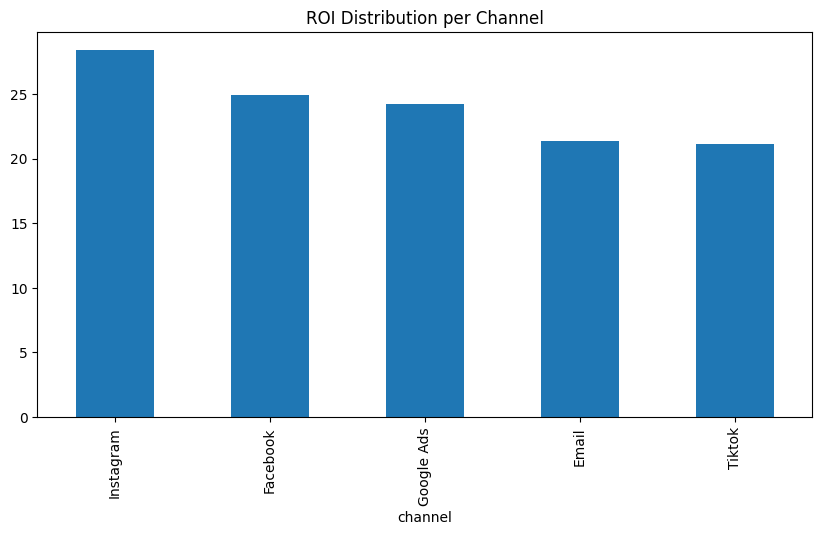

In [146]:
marketing['ROI'] = (marketing['revenue'] - marketing['spend']) / marketing['spend']
marketing.groupby('channel')['ROI'].mean()\
.sort_values(ascending=False)\
.plot(kind='bar',title='ROI Distribution per Channel',figsize=(10,5))

Instagram leads with an average ROI of ~28x — meaning every pound spent 
returned 28 in revenue. Facebook and Google Ads follow closely at ~25x and 
~24x. Email and TikTok sit at the bottom, both around 21x.

Honestly, the gap between channels is smaller than I expected. We're talking 
~7 points between best and worst — not a dramatic difference. No channel is 
bleeding money, but Instagram is consistently pulling ahead.

**What this doesn't tell us:**

ROI alone doesn't settle the budget question. Instagram might have a high ROI 
on a small spend — scale it up and the returns could drop. The next step is 
plotting ROI against actual spend per channel to see if the high performers 
are getting the budget they deserve.

In [147]:
# marketing.groupby('channel')['CPA'].mean()\
# .sort_values(ascending=True)\
# .plot(kind='bar',title='CPA Distribution per Channel',figsize=(10,5))

#

Observations:
Facebook is the cheapest channel to get to Lead (Customer)

[Text(3, 0, '59'),
 Text(3, 0, '60'),
 Text(3, 0, '59'),
 Text(3, 0, '60'),
 Text(3, 0, '61')]

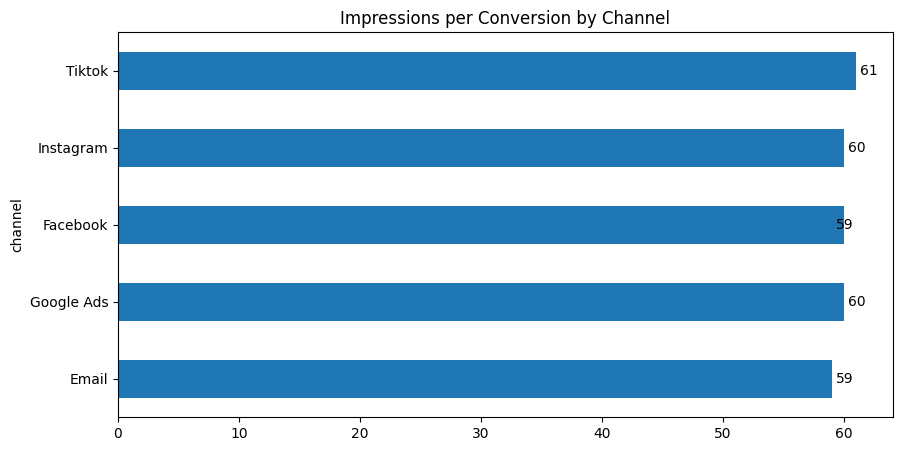

In [148]:
impression_conv = marketing.groupby('channel').agg(
    total_impressions  = ('impressions', 'sum'),
    total_conversions  = ('conversions', 'sum')
).reset_index()

# Add a ratio — impressions per conversion (higher = worse efficiency)
impression_conv['impressions_per_conversion'] = (
    impression_conv['total_impressions'] / impression_conv['total_conversions']
).round(0)
impression_conv['impressions_per_conversion'].plot(kind='barh', title='Impressions per Conversion by Channel', figsize=(10,5))

ax = impression_conv.set_index('channel')['impressions_per_conversion'] \
    .sort_values(ascending=True) \
    .plot(kind='barh', title='Impressions per Conversion by Channel', figsize=(10,5))
ax.bar_label(ax.containers[0], padding=3)

All channels need ~60 impressions to get one conversion. That's a synthetic data artifact — in real data this would vary significantly and tell you which channel has the best audience targeting.

### ROI vs Spend per Channel


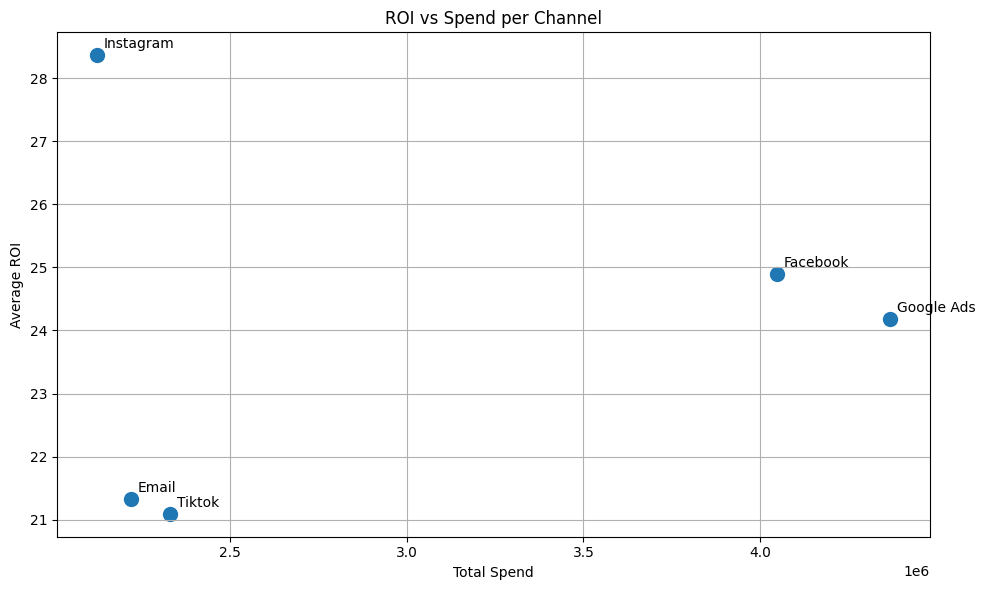

In [149]:
channel_summary = marketing.groupby('channel')\
.agg(
    avg_roi = ('ROI','mean'),
    spend = ('spend','sum')
).reset_index()

fig , ax = plt.subplots(figsize=(10,6))
ax.scatter(channel_summary['spend'], channel_summary['avg_roi'],s=100)
for _ , row in channel_summary.iterrows():
    ax.annotate(row['channel'], xy=(row['spend'], row['avg_roi']), xytext=(5,5), textcoords='offset points')
    
plt.title('ROI vs Spend per Channel')
plt.xlabel('Total Spend')   
plt.ylabel('Average ROI')
plt.grid(True)
plt.tight_layout()
plt.show()

In [150]:
channel_summary.head(5)

,channel,avg_roi,spend
0,Email,21.321915,2220658
1,Facebook,24.894994,4046995
2,Google Ads,24.188659,4366670
3,Instagram,28.364587,2123133
4,Tiktok,21.092625,2329507


Observations:

Instagram sits in the top-left corner: highest ROI (~28x) but one of the lowest spends (~2.3M). That's the most interesting data point on this chart. You're getting the best returns from a channel that isn't even getting serious budget.
Google Ads is the opposite story. Most spend (~4.4M), but ROI dropped to ~24x. More money going in, less efficiency coming out. That's worth asking about — is the audience too broad? Are the keywords too competitive?
Facebook lands in a decent spot. High spend (~4M) with ROI around 25x. Not as efficient as Instagram, but at least the returns justify the investment.
Email and TikTok are both low spend and low ROI (~21x). Email being low ROI is a bit surprising — it's usually a cheap channel. Might be worth checking the CPA on email specifically, since low ROI doesn't always mean it's a bad channel if the spend itself is tiny.

*If Instagram returns 28x on 2.3M spend, what happens if we shift 1M from Google Ads to Instagram?*

### Calculate the KPIs 

In [151]:
marketing['CTR']  = marketing['clicks'] / marketing['impressions']      
marketing['CVR']  = marketing['conversions'] / marketing['clicks']         
marketing['CPC']  = marketing['spend'] / marketing['clicks']               
marketing['CPA'] = marketing['spend'] / marketing['conversions'].replace(0, float('nan'))       
marketing['ROAS'] = marketing['revenue'] / marketing['spend']             
kpi_summary = marketing.groupby('channel').agg(
    avg_CTR  = ('CTR',  'mean'),
    avg_CVR  = ('CVR',  'mean'),
    avg_CPC  = ('CPC',  'mean'),
    avg_CPA  = ('CPA',  'mean'),
    avg_ROI  = ('ROI',  'mean'),
    avg_ROAS = ('ROAS', 'mean'),
    total_spend    = ('spend','sum'),
    total_revenue  = ('revenue','sum'),
    total_conversions = ('conversions', 'sum')
).reset_index()

print(kpi_summary.to_string(index=False))

   channel  avg_CTR  avg_CVR  avg_CPC    avg_CPA   avg_ROI  avg_ROAS  total_spend  total_revenue  total_conversions
     Email 0.101325 0.167451 7.860182 128.632740 21.321915 22.321915      2220658       22895596             188802
  Facebook 0.101621 0.160692 6.628602  97.892684 24.894994 25.894994      4046995       42690978             336943
Google Ads 0.099245 0.169166 7.095864 135.439889 24.188659 25.188659      4366670       44787524             364857
 Instagram 0.103507 0.159062 8.283400 161.579115 28.364587 29.364587      2123133       21333859             172653
    Tiktok 0.098844 0.164309 8.125648 121.714601 21.092625 22.092625      2329507       23130391             184328


# Campaign analysis 

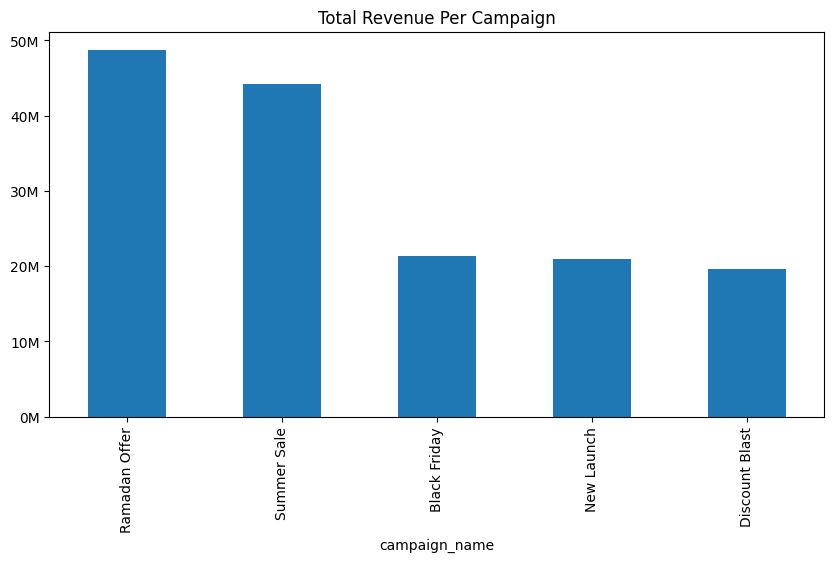

In [152]:
import matplotlib.ticker as ticker

ax = marketing.groupby('campaign_name')['revenue'].sum()\
    .sort_values(ascending=False)\
    .plot(kind='bar', title='Total Revenue Per Campaign', figsize=(10,5))
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
ax.yaxis.set_major_formatter(formatter)

Ramadan Offer and Summer Sale generate more than double the revenue of every other campaign — ~49M and ~44M compared to Black Friday, New Launch, and Discount Blast all sitting flat around 20-21M.
The bottom three campaigns are nearly identical in revenue, which suggests they're either targeting the same audience, running on the same budget,— either way, they're not differentiating themselves at all.

### CVR Distribution per Campaign

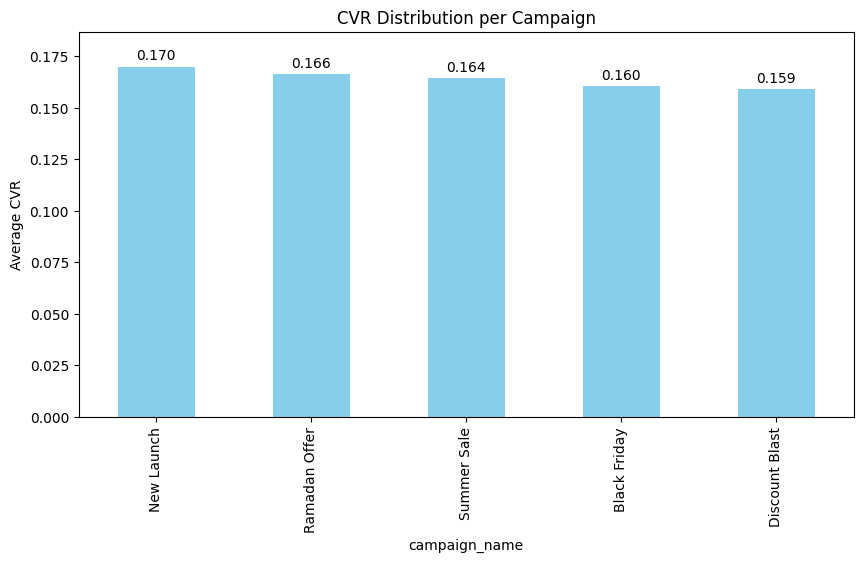

In [153]:
import matplotlib.pyplot as plt

cvr_data = marketing.groupby('campaign_name')['CVR'].mean().sort_values(ascending=False)

ax = cvr_data.plot(kind='bar', title='CVR Distribution per Campaign', figsize=(10, 5), color='skyblue')

ax.bar_label(ax.containers[0], padding=3, fmt='%.3f')

ax.set_ylim(0, cvr_data.max() * 1.1)

plt.ylabel('Average CVR')
plt.show()

### Observations

- **CVR is very consistent across campaigns** (tight range: **0.159 → 0.170**).
- **Top performer:** *New Launch* at **~0.170 CVR**.
- **Close followers:** *Ramadan Offer* (**~0.166**) and *Summer Sale* (**~0.164**) — basically the same tier.
- **Lowest CVR:** *Discount Blast* (**~0.159**) and *Black Friday* (**~0.160**) — slightly behind, but not dramatically.

**Takeaway:** Differences are small, so **campaign ranking by CVR alone isn’t strong enough** to drive big budget decisions without adding volume (clicks), cost (CPA), and value (revenue/ROAS).

### Total ROI Per Campaign

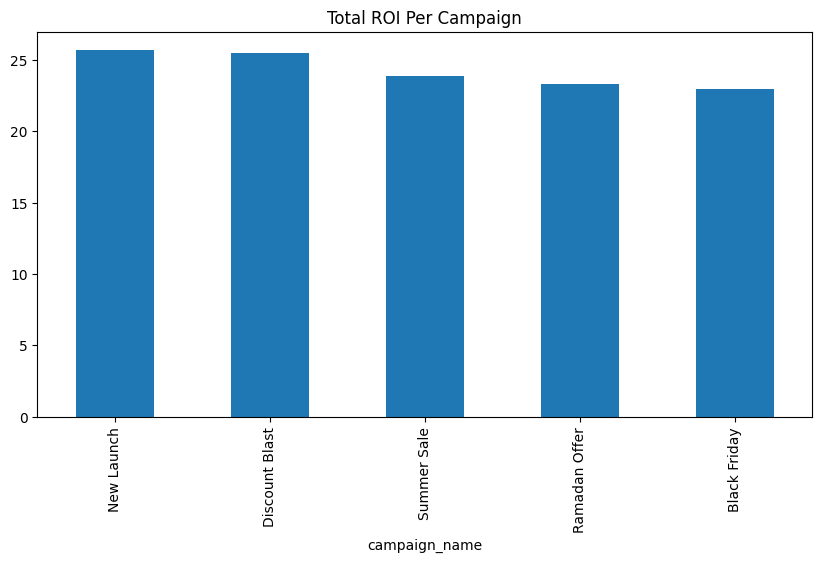

In [154]:
import matplotlib.ticker as ticker

ax = marketing.groupby('campaign_name')['ROI'].mean()\
    .sort_values(ascending=False)\
    .plot(kind='bar', title='Total ROI Per Campaign', figsize=(10,5))



### Observations :

- **New Launch and Discount Blast sit at the top** — both around **~25–26x ROI**.  
  That’s the “best on paper” group, but the lead isn’t massive.

- **Summer Sale is the middle ground** at roughly **~24x**.  
  Solid, but clearly a step below the top two.

- **Ramadan Offer and Black Friday are at the bottom** in this chart, both around **~23x**.  
  They’re not failing — they’re just the lowest ROI in a pretty tight pack.

**Big picture:** the gap from best to worst is only **~2–3 ROI points** (about **~26x → ~23x**).  
So this isn’t a “one campaign is crushing it and the rest are broken” story — **everything is clustered.**


   campaign_id   campaign_name  budget  actual_spend  spend_variance  \
0       CMP100     Summer Sale   33070          7736           25334   
1       CMP101    Black Friday   42649         19950           22699   
2       CMP102    Black Friday   12837          9962            2875   
3       CMP103    Black Friday    5302         35692          -30390   
4       CMP104   Ramadan Offer   42650         14710           27940   
5       CMP105  Discount Blast   44874          9651           35223   
6       CMP106  Discount Blast   30554         51114          -20560   
7       CMP107      New Launch   41614         21086           20528   
8       CMP108     Summer Sale   39359         30513            8846   
9       CMP110    Black Friday   18952          8872           10080   
10      CMP112     Summer Sale   23686         16664            7022   
11      CMP113      New Launch   17576         16339            1237   
12      CMP114     Summer Sale   18532          4672           1

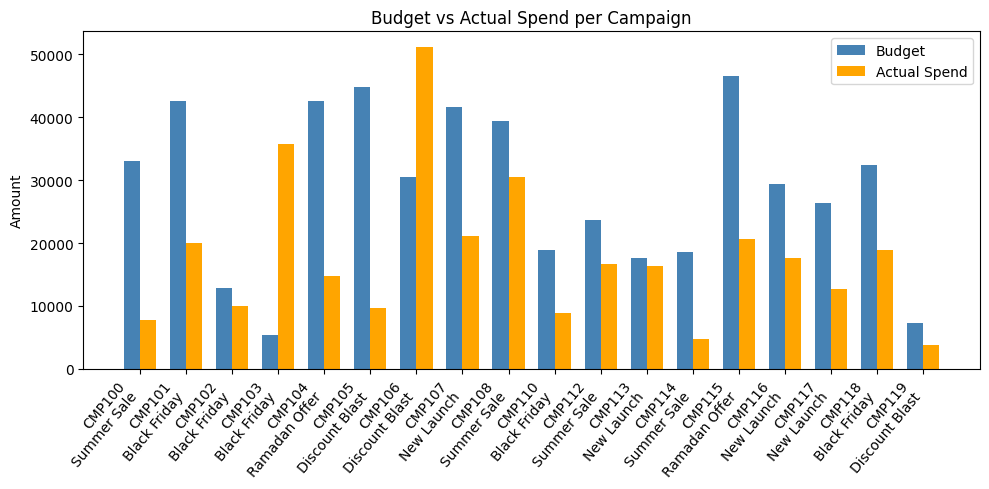

In [155]:
campaign_spend = marketing.groupby('campaign_id')['spend'].sum().reset_index()
campaign_spend.columns = ['campaign_id', 'actual_spend']

budget_check = campaign_spend.merge(campaigns[['campaign_id', 'campaign_name', 'budget']], 
                                     on='campaign_id', how='inner')

budget_check['spend_variance'] = budget_check['budget'] - budget_check['actual_spend']
budget_check['variance_pct'] = (budget_check['spend_variance'] / budget_check['budget']) * 100

# Create a unique label combining ID + name
budget_check['label'] = budget_check['campaign_id'] + '\n' + budget_check['campaign_name']

print(budget_check[['campaign_id', 'campaign_name', 'budget', 'actual_spend', 'spend_variance', 'variance_pct']].round(2))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(budget_check))
width = 0.35

ax.bar([i - width/2 for i in x], budget_check['budget'], width, label='Budget', color='steelblue')
ax.bar([i + width/2 for i in x], budget_check['actual_spend'], width, label='Actual Spend', color='orange')

ax.set_xticks(list(x))
ax.set_xticklabels(budget_check['label'], rotation=50, ha='right')
ax.set_title('Budget vs Actual Spend per Campaign')
ax.set_ylabel('Amount')
ax.legend()
plt.tight_layout()
plt.show()

In [156]:
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])

campaigns['duration_days'] = (campaigns['end_date'] - campaigns['start_date']).dt.days

# Join with budget_check you already have
budget_check = budget_check.merge(campaigns[['campaign_id', 'start_date', 'end_date', 'duration_days']], 
                                   on='campaign_id', how='left')

budget_check['spend_per_day'] = budget_check['actual_spend'] / budget_check['duration_days']
budget_check['budget_per_day'] = budget_check['budget'] / budget_check['duration_days']

print(budget_check[['campaign_name', 'duration_days', 'actual_spend', 'spend_per_day', 'budget_per_day']].round(2))


     campaign_name  duration_days  actual_spend  spend_per_day  budget_per_day
0      Summer Sale             51          7736         151.69          648.43
1     Black Friday             59         19950         338.14          722.86
2     Black Friday             17          9962         586.00          755.12
3     Black Friday             43         35692         830.05          123.30
4    Ramadan Offer             25         14710         588.40         1706.00
5   Discount Blast             14          9651         689.36         3205.29
6   Discount Blast             19         51114        2690.21         1608.11
7       New Launch             17         21086        1240.35         2447.88
8      Summer Sale             11         30513        2773.91         3578.09
9     Black Friday             22          8872         403.27          861.45
10     Summer Sale             48         16664         347.17          493.46
11      New Launch             35         16339     

C:\Users\ysyzy\AppData\Local\Temp\ipykernel_14712\1093490179.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(budget_check['campaign_id'], rotation=50)


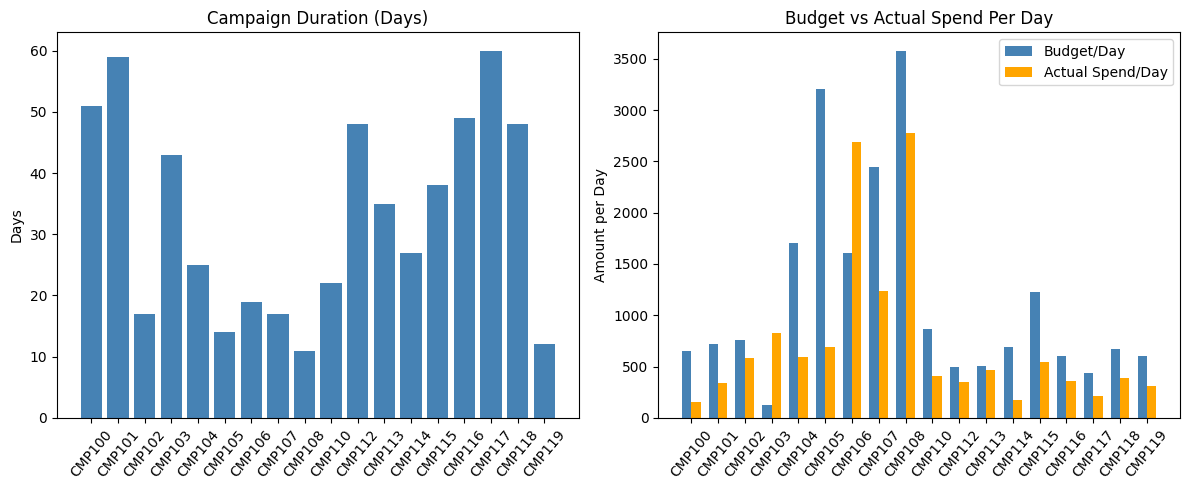

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Duration vs Actual Spend
axes[0].bar(budget_check['campaign_id'], budget_check['duration_days'], color='steelblue')
axes[0].set_title('Campaign Duration (Days)')
axes[0].set_ylabel('Days')
axes[0].set_xticklabels(budget_check['campaign_id'], rotation=50)

# Plot 2: Spend per Day vs Budget per Day
x = range(len(budget_check))
width = 0.35
axes[1].bar([i - width/2 for i in x], budget_check['budget_per_day'], width, label='Budget/Day', color='steelblue')
axes[1].bar([i + width/2 for i in x], budget_check['spend_per_day'], width, label='Actual Spend/Day', color='orange')
axes[1].set_title('Budget vs Actual Spend Per Day')
axes[1].set_ylabel('Amount per Day')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(budget_check['campaign_id'], rotation=50)
axes[1].legend()

plt.tight_layout()
plt.show()

CMP103 — small budget, massive overspend, long duration (~42 days). The worst case in the dataset. Either budget was entered wrong or spend ran completely unchecked.
CMP106 — also overspending per day based on the chart
CMP108 — closest to proper budget execution, orange nearly matches blue
CMP105 — opposite problem, barely spent anything despite a large daily budget

### the summary of campaign analysis
From the full campaign analysis here's what we actually found:

Revenue

Ramadan Offer and Summer Sale dominate revenue — seasonal campaigns clearly outperform the rest
Black Friday, New Launch, Discount Blast are all flat — no real differentiation between them

Budget Control

CMP103 (Black Friday) is a serious problem — 5k budget, 35k spent, 42 days running. Either a data error or zero budget control
CMP106 (Discount Blast) also overspending daily — smaller scale but same pattern
CMP105 (Discount Blast) is the opposite — 44k budget, barely 900 spent. Campaign that never really ran
Most other campaigns underspent, meaning allocated budget was wasted

Duration vs Spend

Longer campaigns don't necessarily spend more — CMP117 ran 60 days but spent very little per day
CMP108 is the only campaign that executed its budget properly — orange matched blue


The one honest business conclusion:
The business has a budget execution problem, not a campaign strategy problem. The top performing campaigns (Ramadan, Summer Sale) are also underspending. If CMP104 (Ramadan Offer) left 27k unspent and still generated the highest revenue, the question is — what would have happened if it actually used its full budget?

## Region Analysis

     region  total_spend  total_revenue   ROI    CPA   CVR
0      Alex      2606182       24222811  8.29  13.34  0.16
1     Cairo      4865860       50967550  9.47  11.80  0.17
2  Mansoura      2604655       27654787  9.62  11.60  0.17
3     Tanta      2526594       27002876  9.69  11.60  0.17
4   Unknown      2483672       24990324  9.06  12.57  0.17


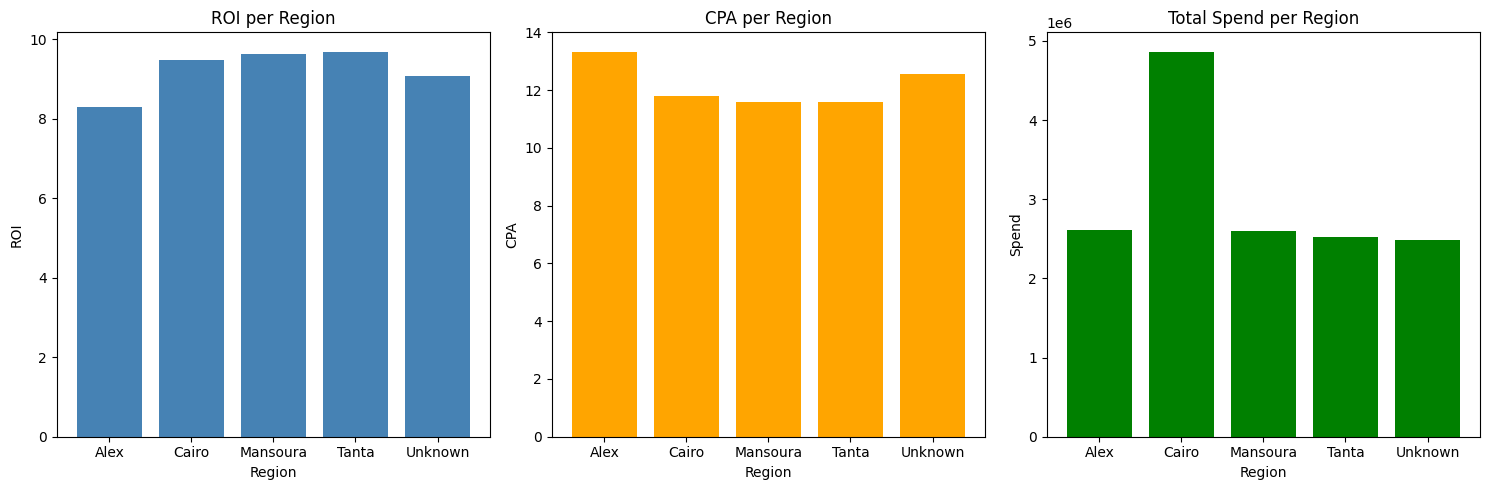

In [158]:
region_analysis = marketing.groupby('region').agg(
    total_spend=('spend', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_conversions=('conversions', 'sum'),
    total_clicks=('clicks', 'sum'),
    total_impressions=('impressions', 'sum')
).reset_index()

region_analysis['ROI'] = (region_analysis['total_revenue'] - region_analysis['total_spend']) / region_analysis['total_spend']
region_analysis['CPA'] = region_analysis['total_spend'] / region_analysis['total_conversions']
region_analysis['CVR'] = region_analysis['total_conversions'] / region_analysis['total_clicks']

print(region_analysis[['region', 'total_spend', 'total_revenue', 'ROI', 'CPA', 'CVR']].round(2))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(region_analysis['region'], region_analysis['ROI'], color='steelblue')
axes[0].set_title('ROI per Region')
axes[0].set_ylabel('ROI')
axes[0].set_xlabel('Region')

axes[1].bar(region_analysis['region'], region_analysis['CPA'], color='orange')
axes[1].set_title('CPA per Region')
axes[1].set_ylabel('CPA')
axes[1].set_xlabel('Region')

axes[2].bar(region_analysis['region'], region_analysis['total_spend'], color='green')
axes[2].set_title('Total Spend per Region')
axes[2].set_ylabel('Spend')
axes[2].set_xlabel('Region')

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Total Revenue per Region'}, xlabel='region'>

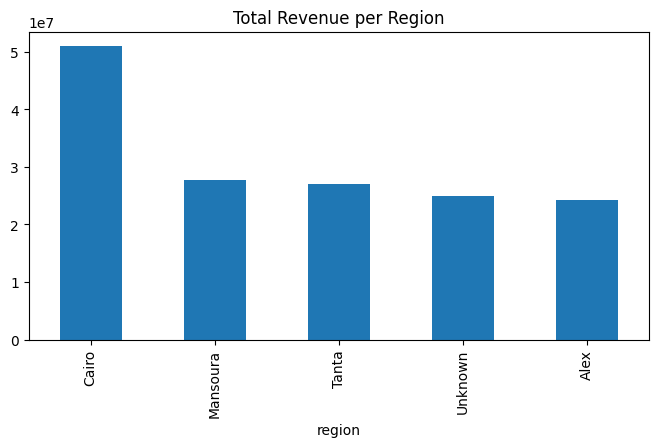

In [159]:
marketing.groupby('region')['revenue'].sum().sort_values(ascending=False).plot(kind='bar', title='Total Revenue per Region', figsize=(8,4))

*Cairo* is the biggest revenue engine in the dataset — 50M, nearly double everyone else. But it's also the most expensive region to operate in, sitting third on ROI and third on CPA. The volume is real, the efficiency isn't. You wouldn't cut it, but you'd want to know where exactly that budget is going.

*Tanta and Mansoura* are the quiet overperformers. Both run on roughly 2.5M in spend, both sit at the top for ROI and CPA, and Mansoura pulls second place in total revenue on top of that. These two are doing more with less — if that efficiency holds at higher spend levels, they're the obvious candidates for more budget.

*Alex* is the one region that's hard to defend. Lowest revenue, highest CPA, worst ROI. It's not catastrophically bad, but nothing in the numbers makes a case for growing it. At minimum it needs a strategy review before the next budget cycle.

**summary**: Cairo runs the volume, Tanta and Mansoura run the efficiency, and Alex is coasting on budget it hasn't earned. The gap between Cairo's spend share and its ROI rank is the most actionable finding here — not a reason to defund it, but a clear signal that how the money is spent there matters more than how much.

### Device Analysis

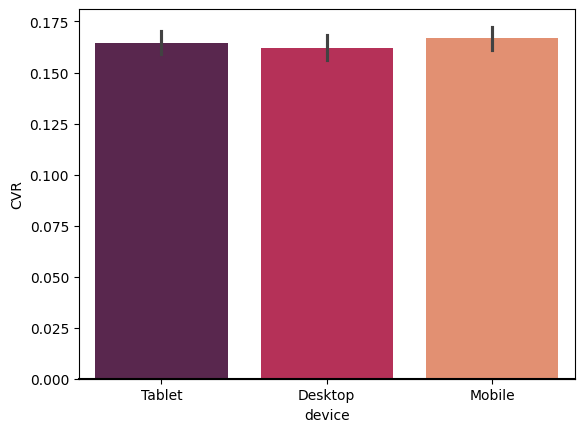

In [160]:

from matplotlib.pyplot import axhline


marketing.groupby('device')['CVR'].mean()
sns.barplot(x=marketing['device'], y=marketing['CVR'], hue=marketing['device'], palette="rocket")
axhline(0, color="k", clip_on=False)


this answer the hypothesis that mobile struggle to compelete purchase 
All three devices have nearly identical CVR (~0.163-0.168). Mobile is actually the highest of the three, not the lowest
So the concern that mobile users struggle to convert because the site is slow or hard to use — doesn't show up in this data. 

    device  total_spend  total_revenue   ROI    CPA
0  Desktop      5091722       51118866  9.04  12.41
1   Mobile      4958916       53370335  9.76  11.65
2   Tablet      5036325       50349147  9.00  12.24


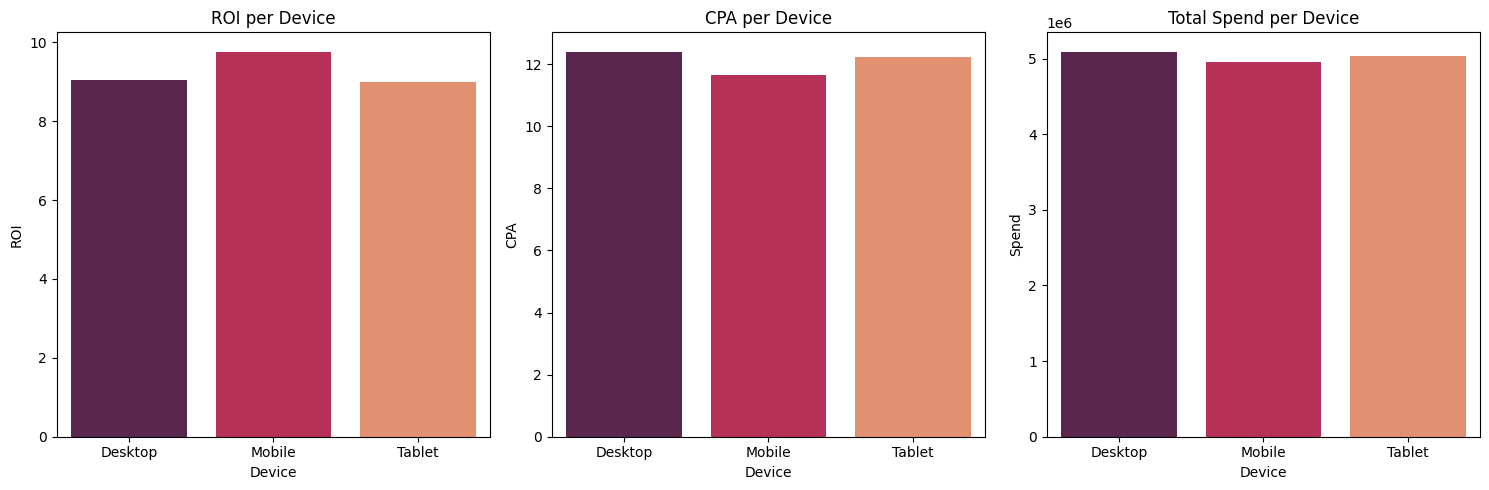

In [161]:

device_analysis = marketing.groupby('device').agg(
    total_spend=('spend', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_conversions=('conversions', 'sum'),
    total_clicks=('clicks', 'sum')
).reset_index()

device_analysis['ROI'] = (device_analysis['total_revenue'] - device_analysis['total_spend']) / device_analysis['total_spend']
device_analysis['CPA'] = device_analysis['total_spend'] / device_analysis['total_conversions']

print(device_analysis[['device', 'total_spend', 'total_revenue', 'ROI', 'CPA']].round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=device_analysis, x='device', y='ROI', hue='device', 
            palette='rocket', ax=axes[0])
axes[0].set_title('ROI per Device')
axes[0].set_xlabel('Device')
axes[0].set_ylabel('ROI')

sns.barplot(data=device_analysis, x='device', y='CPA', hue='device', 
            palette='rocket', ax=axes[1])
axes[1].set_title('CPA per Device')
axes[1].set_xlabel('Device')
axes[1].set_ylabel('CPA')

sns.barplot(data=device_analysis, x='device', y='total_spend', hue='device', 
            palette='rocket', ax=axes[2])
axes[2].set_title('Total Spend per Device')
axes[2].set_xlabel('Device')
axes[2].set_ylabel('Spend')

plt.tight_layout()
plt.show()

That said, mobile edges out the other two on both metrics that matter. Highest ROI, lowest CPA. Desktop sits at the other end — most expensive per conversion, lowest return. Not by a dramatic margin, but the direction is consistent.
The spend split is worth noting. Budget is divided almost equally across desktop, mobile, and tablet.

### Time Analysis

C:\Users\ysyzy\AppData\Local\Temp\ipykernel_14712\1514447503.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=timing_check, x='campaign_id', y='start_diff',
C:\Users\ysyzy\AppData\Local\Temp\ipykernel_14712\1514447503.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=timing_check, x='campaign_id', y='end_diff',


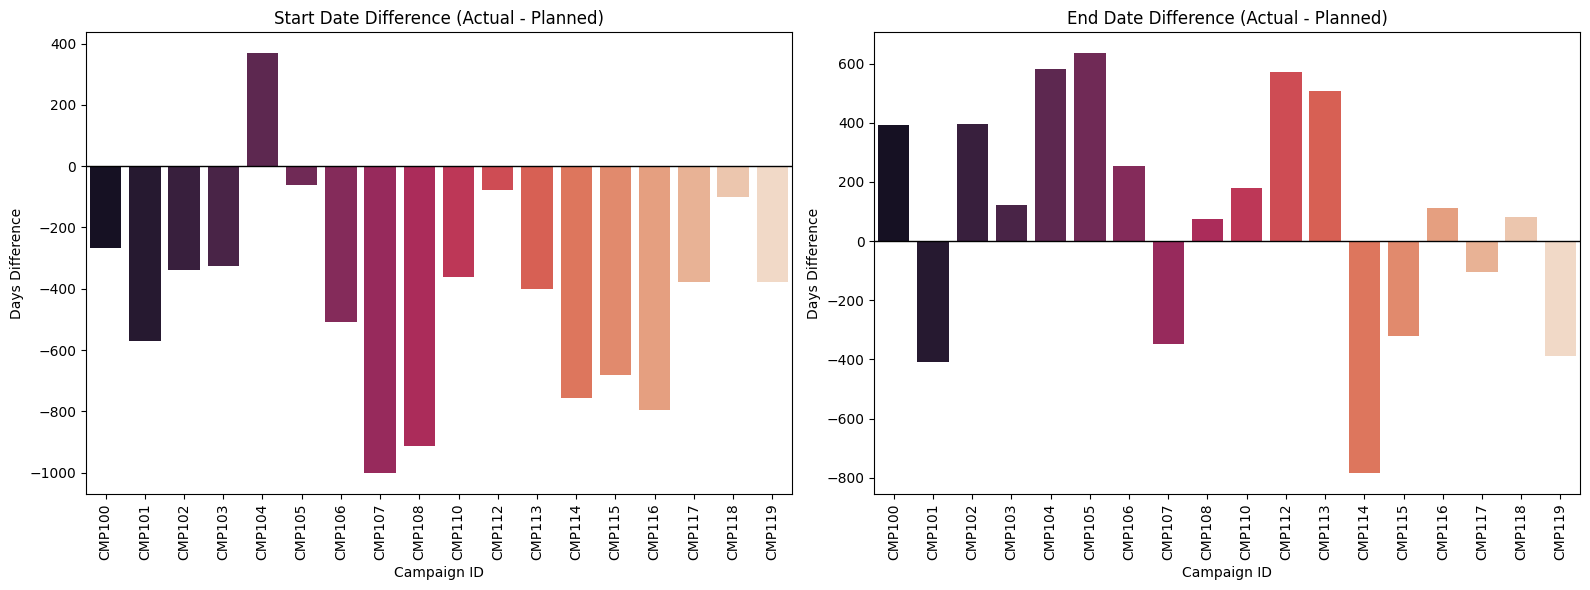

In [162]:
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])

actual_dates = marketing.groupby('campaign_id')['date'].agg(['min', 'max']).reset_index()
actual_dates.columns = ['campaign_id', 'actual_start', 'actual_end']

timing_check = campaigns[['campaign_id', 'campaign_name', 'start_date', 'end_date']].merge(
    actual_dates, on='campaign_id', how='inner'
)

timing_check['start_diff'] = (timing_check['actual_start'] - timing_check['start_date']).dt.days
timing_check['end_diff'] = (timing_check['actual_end'] - timing_check['end_date']).dt.days


fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

sns.barplot(data=timing_check, x='campaign_id', y='start_diff', 
            palette='rocket', ax=axes[0])
axes[0].set_title('Start Date Difference (Actual - Planned)')
axes[0].set_xlabel('Campaign ID')
axes[0].set_ylabel('Days Difference')
axes[0].tick_params(axis='x', rotation=90)
axes[0].axhline(0, color='black', linewidth=1)

sns.barplot(data=timing_check, x='campaign_id', y='end_diff', 
            palette='rocket', ax=axes[1])
axes[1].set_title('End Date Difference (Actual - Planned)')
axes[1].set_xlabel('Campaign ID')
axes[1].set_ylabel('Days Difference')
axes[1].tick_params(axis='x', rotation=90)
axes[1].axhline(0, color='black', linewidth=1) 

plt.tight_layout()
plt.show()

Prevalent Early Starts: Most campaigns (e.g., CMP107, CMP108) started nearly 3 years earlier than planned. This usually indicates a data entry error or placeholder dates in the planning phase.

The Late Outlier: CMP104 is a rare exception, starting roughly 380 days late.

Unpredictable Endings: Unlike the start dates, end dates are inconsistent. Some campaigns (CMP105, CMP112) ran over 500 days past schedule, while CMP114 ended 800 days early.

I think this happend because the data is synthetic

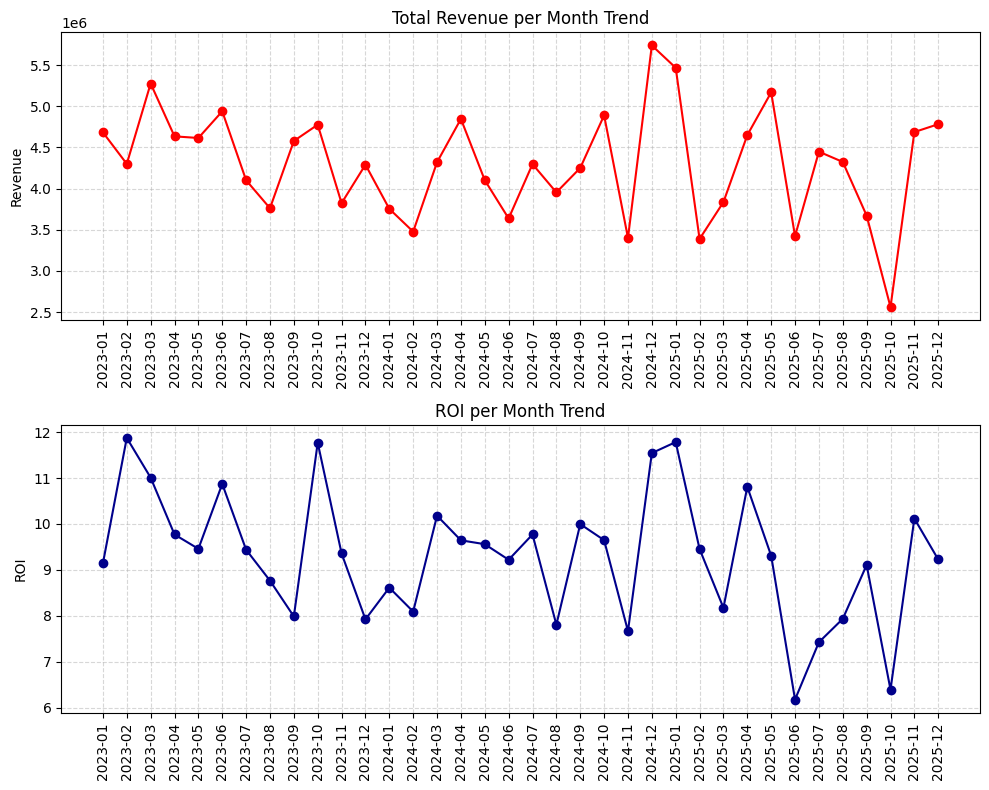

In [163]:
marketing['year_month'] = marketing['date'].dt.to_period('M')

monthly = marketing.groupby('year_month').agg(
    total_revenue=('revenue', 'sum'),
    total_spend=('spend', 'sum'),
    total_conversions=('conversions', 'sum')
).reset_index()

monthly['ROI'] = (monthly['total_revenue'] - monthly['total_spend']) / monthly['total_spend']
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(monthly['year_month_str'], monthly['total_revenue'], 
             color='red', marker='o')
axes[0].set_title('Total Revenue per Month Trend')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(monthly['year_month_str'], monthly['ROI'], 
             color='darkblue', marker='o')
axes[1].set_title('ROI per Month Trend')
axes[1].set_ylabel('ROI')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Revenue:**
Mar 2023 is the first major peak (~5.3M). After that revenue drifts mostly between 3.8–4.9M with no clear direction through all of 2023 and 2024. Nov 2024 crashes to the lowest point in that stretch (~3.4M), then Dec 2024 spikes sharply to the highest single point in the entire dataset (~5.7M). Jan 2025 stays high (~5.5M) then Feb 2025 drops hard again (~3.4M). The most dramatic single event is Oct 2025 — revenue collapses to ~2.5M, the absolute floor of the entire three year period, before recovering in Nov–Dec 2025.

**ROI:**
Feb 2023 hits the first major peak (~11.9x). ROI then falls through mid-2023, bottoming at Sep 2023 (~8.0x). It recovers into Nov 2023 (~11.8x) then drops again. The pattern repeats — peaks around Dec 2024–Jan 2025 (~11.6x), then a steady decline through 2025. Jun 2025 hits the worst ROI in the dataset (~6.2x) and Oct 2025 is nearly as bad (~6.4x).

The real pattern:
The ROI floor is getting lower with each cycle — 2023 floor was ~8x, 2024 floor was ~7.6x, 2025 floor dropped to ~6.2x. Revenue isn't growing but efficiency is quietly eroding. The business isn't collapsing but it's spending more to generate the same revenue over time.

In [164]:
leads.head()


,lead_id,date,campaign_id,channel,status,score
0,L5928,2023-02-03 23:41:00,CMP115,Google Ads,Converted,43
1,L6916,2024-10-13 15:00:00,CMP107,Instagram,Converted,43
2,L2673,2023-09-15 09:21:00,CMP111,Google Ads,Unknown,62
3,L9612,2024-09-26 02:58:00,CMP113,TikTok,Converted,95
4,L9662,2024-07-30 13:29:00,CMP105,Google Ads,New,15


Total Leads     : 1000
Converted       : 271
Conversion Rate : 27.1%


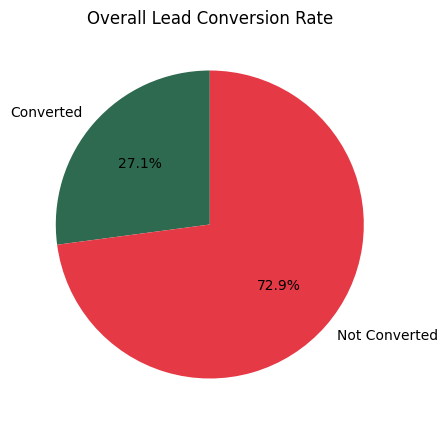

In [165]:
#What is the overall conversion rate?
total_leads = len(leads)
converted = (leads['status'] == 'Converted').sum()
conversion_rate = converted / total_leads * 100

print(f"Total Leads     : {total_leads}")
print(f"Converted       : {converted}")
print(f"Conversion Rate : {conversion_rate:.1f}%")

labels = ['Converted', 'Not Converted']
values = [converted, total_leads - converted]
colors = ['#2d6a4f', '#e63946']

plt.figure(figsize=(6, 5))
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Overall Lead Conversion Rate')
plt.show()



      channel  avg_score  median_score  lead_count
0       Email      48.72          46.0         188
1    Facebook      47.02          47.0         195
2  Google Ads      49.05          50.0         191
3   Instagram      50.16          49.5         216
4      TikTok      48.29          47.0         210


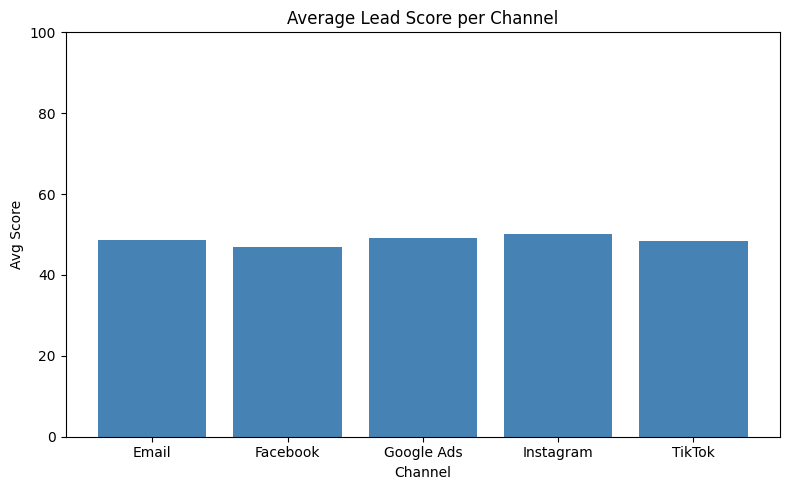

In [166]:
channel_score = leads.groupby('channel').agg(
    avg_score=('score', 'mean'),
    median_score=('score', 'median'),
    lead_count=('score', 'count')
).reset_index()
channel_score.sort_values('avg_score', ascending=False)
print(channel_score.round(2))
plt.figure(figsize=(8, 5))
plt.bar(channel_score['channel'], channel_score['avg_score'], color='steelblue')
plt.title('Average Lead Score per Channel')
plt.xlabel('Channel')
plt.ylabel('Avg Score')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Total Leads     : 1000
Contacted       : 154
Conversion Rate : 15.4%
Total Leads     : 1000
Contacted       : 154
Conversion Rate : 15.4%

Breakdown by channel:
channel
TikTok        35
Instagram     34
Email         32
Facebook      29
Google Ads    24
Name: count, dtype: int64


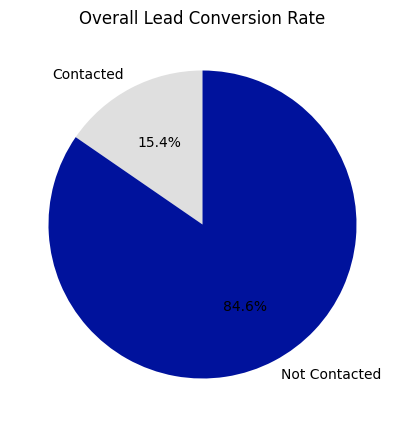

In [167]:
total_leads = len(leads)
contacted = (leads['status'] == 'Contacted').sum()
contacted_rate = contacted / total_leads * 100

print(f"Total Leads     : {total_leads}")
print(f"Contacted       : {contacted}")
print(f"Conversion Rate : {contacted_rate:.1f}%")

labels = ['Contacted', 'Not Contacted']
values = [contacted, total_leads - contacted]
colors = ["#dfdfdf", "#00129c"]

# Create a filtered DataFrame containing only the contacted leads
contacted_df = leads[leads['status'] == 'Contacted']

print(f"Total Leads     : {total_leads}")
print(f"Contacted       : {contacted}")
print(f"Conversion Rate : {contacted_rate:.1f}%")
print()
print("Breakdown by channel:")
# Now perform value_counts() on the filtered DataFrame
print(contacted_df['channel'].value_counts())
plt.figure(figsize=(6, 5))
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Overall Lead Conversion Rate')
plt.show()




   campaign_id  count  total  lost_pct
17      CMP117     21     54      38.9
11      CMP111     20     56      35.7
15      CMP115     16     45      35.6
7       CMP107     18     53      34.0
18      CMP118     12     37      32.4
0       CMP100     13     42      31.0
2       CMP102     12     39      30.8
9       CMP109     14     47      29.8
14      CMP114     14     47      29.8
3       CMP103     14     48      29.2
4       CMP104     11     41      26.8
19      CMP119     12     46      26.1
10      CMP110     14     54      25.9
20      CMP120     12     47      25.5
12      CMP112      8     33      24.2
6       CMP106      9     38      23.7
8       CMP108     13     55      23.6
5       CMP105     13     56      23.2
13      CMP113     14     61      23.0
16      CMP116     13     58      22.4
1       CMP101      8     43      18.6


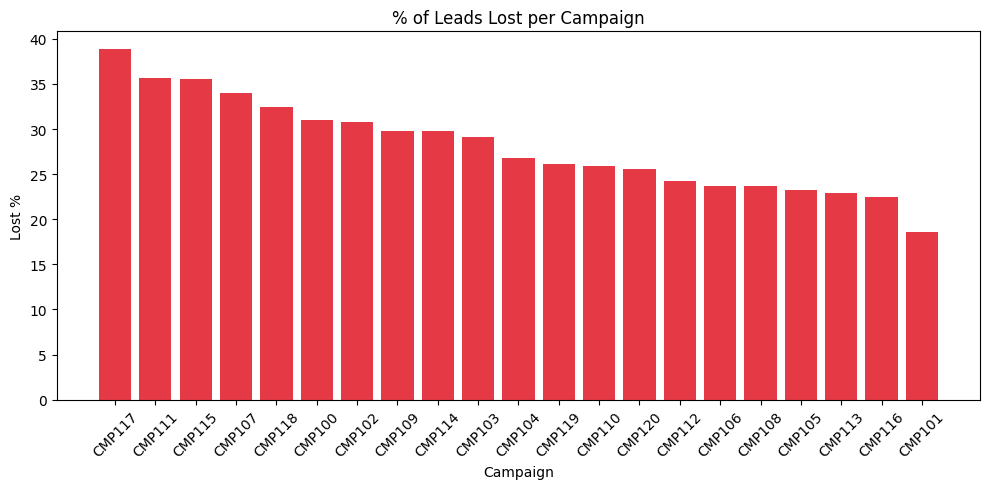

In [168]:
campaign_status = leads.groupby(['campaign_id', 'status']).size().reset_index(name='count')
campaign_total = leads.groupby('campaign_id').size().reset_index(name='total')

campaign_lost = campaign_status[campaign_status['status'] == 'Lost'].merge(
    campaign_total, on='campaign_id'
)
campaign_lost['lost_pct'] = campaign_lost['count'] / campaign_lost['total'] * 100
campaign_lost = campaign_lost.sort_values('lost_pct', ascending=False)

print(campaign_lost[['campaign_id', 'count', 'total', 'lost_pct']].round(1))

# Plot
plt.figure(figsize=(10, 5))
plt.bar(campaign_lost['campaign_id'], campaign_lost['lost_pct'], color='#e63946')
plt.title('% of Leads Lost per Campaign')
plt.xlabel('Campaign')
plt.ylabel('Lost %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [169]:
import pandas as pd

# 1. Define your DataFrames
# df1, df2, df3, df4 = ... (your processed data)

# 2. Use ExcelWriter to handle the multi-sheet output
output_file = 'final_data_report.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    marketing.to_excel(writer, sheet_name='marketing', index=False)
    campaigns.to_excel(writer, sheet_name='campaigns', index=False)
    leads.to_excel(writer, sheet_name='leads', index=False)
    channels.to_excel(writer, sheet_name='channels', index=False)

print(f"Successfully exported all sheets to {output_file}")

Successfully exported all sheets to final_data_report.xlsx
